# Практика: Влияние инициализации и скорости обучения на MNIST

В этом практическом занятии мы исследуем, как начальная инициализация весов и скорость обучения влияют на обучение нейронной сети на реальном наборе данных MNIST (рукописные цифры). Мы будем использовать простую полносвязную сеть (MLP) с двумя скрытыми слоями.

**Цели:**
- Научиться загружать и подготавливать данные MNIST.
- Сравнить различные инициализации (по умолчанию, Xavier, He, случайная большая).
- Исследовать влияние скорости обучения на сходимость.
- Визуализировать процесс обучения и полученные признаки.

**Задание: повторить все действия и сделать выводы для набора данных Fashion-MNIST.**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

## 1. Загрузка и предобработка данных MNIST

Загрузим обучающую и тестовую выборки, нормализуем изображения и создадим DataLoader'ы. Для ускорения эксперимента возьмём только первые 10000 обучающих примеров и 2000 тестовых.

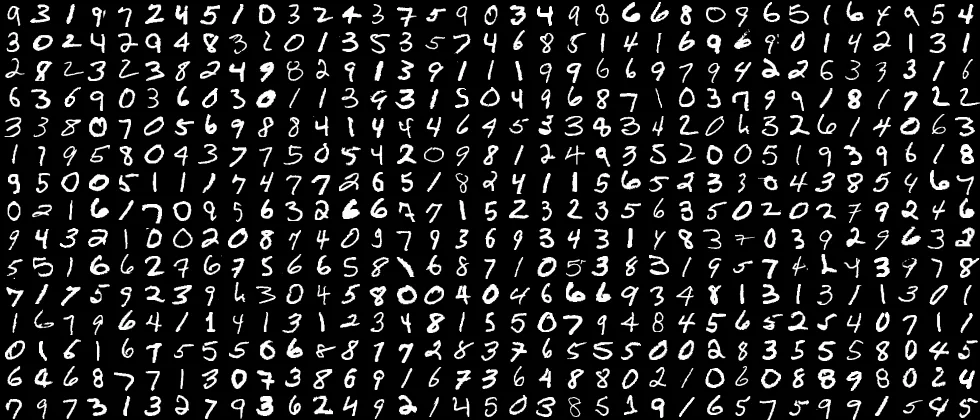

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # среднее и std для MNIST
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Ограничим выборку для быстроты
train_dataset = torch.utils.data.Subset(train_dataset, range(10000))
test_dataset = torch.utils.data.Subset(test_dataset, range(2000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]


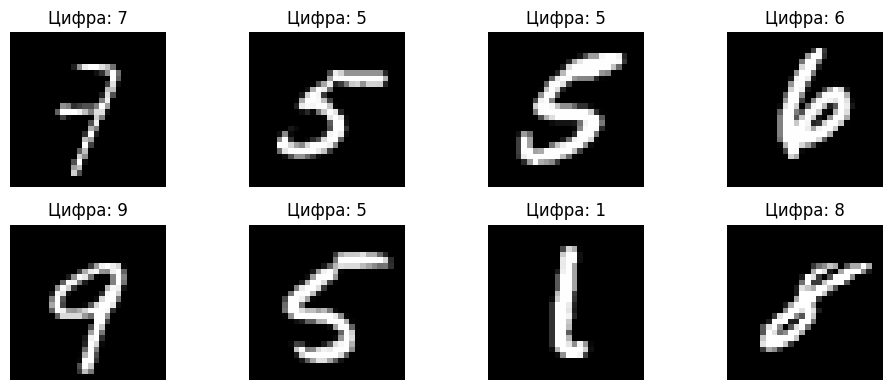

In [ ]:
# Посмотрим на несколько изображений
images, labels = next(iter(train_loader))
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'Цифра: {labels[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Определение модели

Создадим MLP с двумя скрытыми слоями (256 и 128 нейронов) и выходным слоем на 10 классов (softmax не включаем, так как будем использовать CrossEntropyLoss).

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, output_size=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, output_size)
        # без softmax, его добавит loss

    def forward(self, x):
        x = x.view(x.size(0), -1)  # вытягиваем изображения в вектор
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

def init_weights(m, mode='default'):
    if isinstance(m, nn.Linear):
        if mode == 'normal':
            nn.init.normal_(m.weight, mean=0, std=1.0)
            nn.init.zeros_(m.bias)
        elif mode == 'xavier':
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
        elif mode == 'he':
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
        elif mode == 'default':
            pass  # оставляем умолчательную

## 3. Функция для обучения и оценки

Определим функцию, которая принимает модель, загрузчики, число эпох, скорость обучения и тип инициализации, обучает и возвращает историю потерь и точности.

In [ ]:
def train_and_evaluate(model, train_loader, test_loader, epochs=5, lr=0.01, init_mode='default'):
    model.apply(lambda m: init_weights(m, init_mode))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Пустые массивы для накопления истории обучения
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Это только перевод в режим обучения
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Перебор всех жанных из обучающей выборки
        for images, labels in train_loader:
            optimizer.zero_grad()
            # Прямой проход
            outputs = model(images)
            # Текущее значение функции потерь
            loss = criterion(outputs, labels)
            # Обратное распространение ошибки.
            loss.backward()

            # обновление весов модели на основе градиентов.
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Обновление метрик после прохода всех данных
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Оценка на тесте
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = correct_test / total_test
        test_losses.append(epoch_test_loss)
        test_accs.append(epoch_test_acc)

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}')

    return train_losses, test_losses, train_accs, test_accs

## 4. Эксперимент 1: Сравнение инициализаций

Зафиксируем скорость обучения `lr = 0.01` и сравним четыре инициализации: по умолчанию, Xavier, He, случайная нормальная с большой дисперсией (std=1). Обучим каждую модель в течение 5 эпох.

In [ ]:
init_modes = ['default', 'xavier', 'he', 'normal']
histories = {}

for mode in init_modes:
    print(f"\n=== Инициализация: {mode} ===")
    model = MLP()
    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, train_loader, test_loader, epochs=5, lr=0.01, init_mode=mode
    )
    histories[mode] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }


=== Инициализация: default ===
Epoch 1/5 | Train Loss: 1.9573 | Test Loss: 1.5251 | Test Acc: 0.6850
Epoch 2/5 | Train Loss: 0.9627 | Test Loss: 0.8017 | Test Acc: 0.7930
Epoch 3/5 | Train Loss: 0.5600 | Test Loss: 0.5963 | Test Acc: 0.8350
Epoch 4/5 | Train Loss: 0.4358 | Test Loss: 0.5180 | Test Acc: 0.8490
Epoch 5/5 | Train Loss: 0.3774 | Test Loss: 0.4679 | Test Acc: 0.8630

=== Инициализация: xavier ===
Epoch 1/5 | Train Loss: 0.9504 | Test Loss: 0.6451 | Test Acc: 0.8095
Epoch 2/5 | Train Loss: 0.4182 | Test Loss: 0.4899 | Test Acc: 0.8550
Epoch 3/5 | Train Loss: 0.3267 | Test Loss: 0.4220 | Test Acc: 0.8755
Epoch 4/5 | Train Loss: 0.2783 | Test Loss: 0.3885 | Test Acc: 0.8895
Epoch 5/5 | Train Loss: 0.2462 | Test Loss: 0.3631 | Test Acc: 0.8935

=== Инициализация: he ===
Epoch 1/5 | Train Loss: 0.8637 | Test Loss: 0.5982 | Test Acc: 0.8280
Epoch 2/5 | Train Loss: 0.3863 | Test Loss: 0.4546 | Test Acc: 0.8650
Epoch 3/5 | Train Loss: 0.3005 | Test Loss: 0.3974 | Test Acc: 0.8850


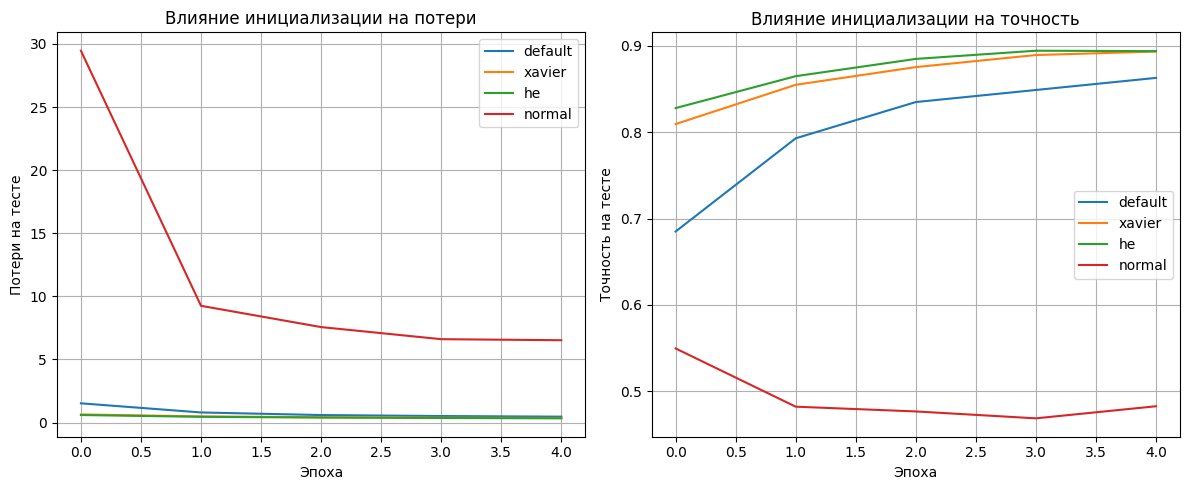

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for mode in init_modes:
    plt.plot(histories[mode]['test_loss'], label=mode)
plt.xlabel('Эпоха')
plt.ylabel('Потери на тесте')
plt.title('Влияние инициализации на потери')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for mode in init_modes:
    plt.plot(histories[mode]['test_acc'], label=mode)
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Влияние инициализации на точность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Вопросы для анализа:**
- Какая инициализация обеспечила наилучшую точность?
- Почему инициализация 'normal' (std=1) работает хуже?
- Соответствуют ли результаты теоретическим ожиданиям (He лучше для ReLU)?

## 5. Эксперимент 2: Влияние скорости обучения

Теперь зафиксируем инициализацию He (как лучшую для ReLU) и сравним три значения скорости обучения: 0.001, 0.01, 0.1.

In [ ]:
lrs = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in lrs:
    print(f"\n=== Learning rate: {lr} ===")
    model = MLP()
    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, train_loader, test_loader, epochs=5, lr=lr, init_mode='he'
    )
    lr_histories[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }


=== Learning rate: 0.001 ===
Epoch 1/5 | Train Loss: 2.1187 | Test Loss: 1.7180 | Test Acc: 0.4480
Epoch 2/5 | Train Loss: 1.3072 | Test Loss: 1.2668 | Test Acc: 0.6265
Epoch 3/5 | Train Loss: 0.9654 | Test Loss: 1.0302 | Test Acc: 0.7055
Epoch 4/5 | Train Loss: 0.7852 | Test Loss: 0.8881 | Test Acc: 0.7425
Epoch 5/5 | Train Loss: 0.6765 | Test Loss: 0.7957 | Test Acc: 0.7690

=== Learning rate: 0.01 ===
Epoch 1/5 | Train Loss: 0.8986 | Test Loss: 0.6154 | Test Acc: 0.8110
Epoch 2/5 | Train Loss: 0.4015 | Test Loss: 0.4750 | Test Acc: 0.8660
Epoch 3/5 | Train Loss: 0.3140 | Test Loss: 0.4158 | Test Acc: 0.8760
Epoch 4/5 | Train Loss: 0.2674 | Test Loss: 0.3767 | Test Acc: 0.8875
Epoch 5/5 | Train Loss: 0.2342 | Test Loss: 0.3553 | Test Acc: 0.8975

=== Learning rate: 0.1 ===
Epoch 1/5 | Train Loss: 0.4489 | Test Loss: 0.4290 | Test Acc: 0.8535
Epoch 2/5 | Train Loss: 0.1702 | Test Loss: 0.5143 | Test Acc: 0.8345
Epoch 3/5 | Train Loss: 0.1082 | Test Loss: 0.2904 | Test Acc: 0.9050
Epo

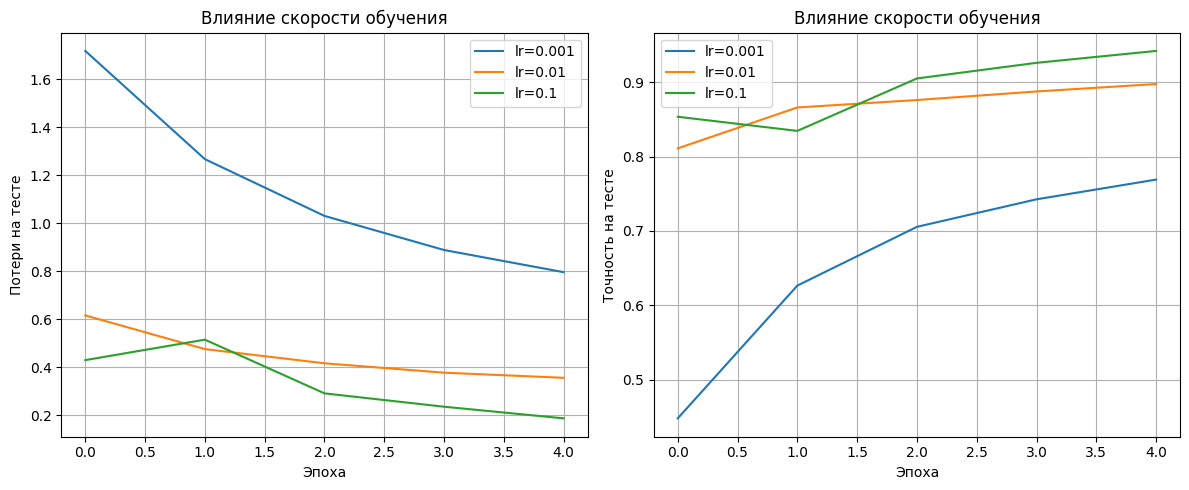

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for lr in lrs:
    plt.plot(lr_histories[lr]['test_loss'], label=f'lr={lr}')
plt.xlabel('Эпоха')
plt.ylabel('Потери на тесте')
plt.title('Влияние скорости обучения')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for lr in lrs:
    plt.plot(lr_histories[lr]['test_acc'], label=f'lr={lr}')
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Влияние скорости обучения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Вопросы:**
- Какое значение learning rate дало наилучший результат?
- Наблюдается ли переобучение или недообучение при каком-либо lr?
- Что произойдёт, если взять lr = 1.0? (можно проверить самостоятельно)

## 6. Визуализация весов первого слоя

Для лучшей модели (например, He + lr=0.01) визуализируем веса первого слоя как изображения 28x28, чтобы увидеть, какие паттерны выучили нейроны.

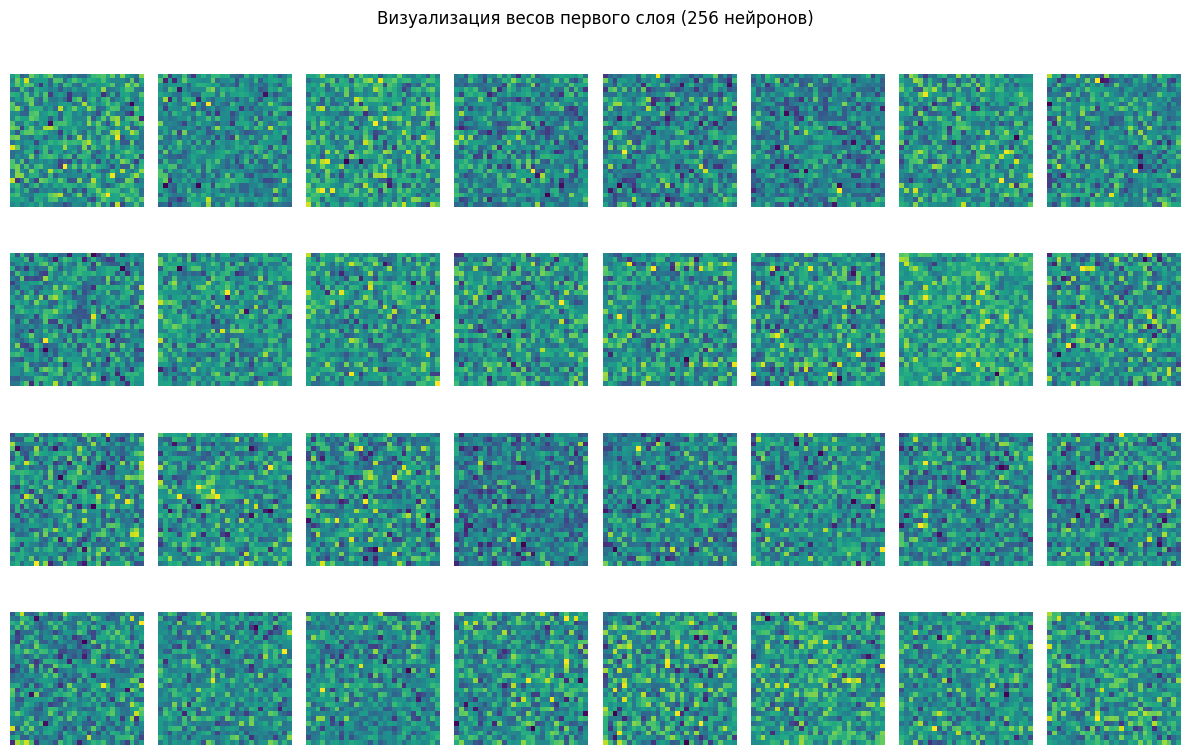

In [ ]:
best_model = histories['he']['model']  # из первого эксперимента
weights = best_model.fc1.weight.detach().cpu().numpy()  # (256, 784)

# Отобразим первые 32 нейрона
plt.figure(figsize=(12,8))
for i in range(32):
    plt.subplot(4,8,i+1)
    w = weights[i].reshape(28,28)
    plt.imshow(w, cmap='viridis')
    plt.axis('off')
plt.suptitle('Визуализация весов первого слоя (256 нейронов)')
plt.tight_layout()
plt.show()

## 7. Выводы

В этом практическом занятии мы:
- Загрузили реальный набор данных MNIST и построили простой MLP.
- Сравнили различные инициализации весов и убедились, что Xavier и He дают лучшую сходимость, чем случайная большая инициализация.
- Исследовали влияние скорости обучения и увидели, что слишком маленький шаг замедляет обучение, а слишком большой может привести к нестабильности.
- Визуализировали веса первого слоя, которые показывают, что нейроны учатся распознавать характерные штрихи цифр.

Эти эксперименты демонстрируют важность правильного выбора гиперпараметров при обучении нейросетей.

1. Загрузка и предобработка данных Fashion-MNIST

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.48MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.5MB/s]


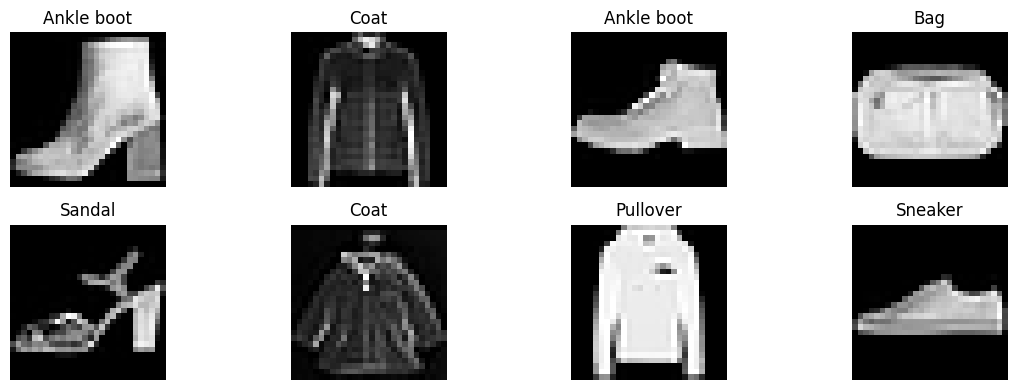

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Загрузка и предобработка данных Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # среднее и std для Fashion-MNIST
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Ограничим выборку для быстроты
train_dataset = torch.utils.data.Subset(train_dataset, range(10000))
test_dataset = torch.utils.data.Subset(test_dataset, range(2000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Названия классов Fashion-MNIST
fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Посмотрим на несколько изображений
images, labels = next(iter(train_loader))
plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'{fashion_classes[labels[i].item()]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

2. Определение модели

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, output_size=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

def init_weights(m, mode='default'):
    if isinstance(m, nn.Linear):
        if mode == 'normal':
            nn.init.normal_(m.weight, mean=0, std=1.0)
            nn.init.zeros_(m.bias)
        elif mode == 'xavier':
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
        elif mode == 'he':
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
        elif mode == 'default':
            pass

3. Функция для обучения и оценки

In [ ]:
def train_and_evaluate(model, train_loader, test_loader, epochs=5, lr=0.01, init_mode='default'):
    model.apply(lambda m: init_weights(m, init_mode))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = correct_test / total_test
        test_losses.append(epoch_test_loss)
        test_accs.append(epoch_test_acc)

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}')

    return train_losses, test_losses, train_accs, test_accs

4. Эксперимент 1: Сравнение инициализаций на Fashion-MNIST


=== Инициализация: default для Fashion-MNIST ===
Epoch 1/5 | Train Loss: 1.7738 | Test Loss: 1.1853 | Test Acc: 0.6215
Epoch 2/5 | Train Loss: 0.9480 | Test Loss: 0.8297 | Test Acc: 0.6990
Epoch 3/5 | Train Loss: 0.7343 | Test Loss: 0.6929 | Test Acc: 0.7560
Epoch 4/5 | Train Loss: 0.6431 | Test Loss: 0.6653 | Test Acc: 0.7260
Epoch 5/5 | Train Loss: 0.5906 | Test Loss: 0.5854 | Test Acc: 0.7890

=== Инициализация: xavier для Fashion-MNIST ===
Epoch 1/5 | Train Loss: 0.9304 | Test Loss: 0.7167 | Test Acc: 0.7380
Epoch 2/5 | Train Loss: 0.5914 | Test Loss: 0.5735 | Test Acc: 0.8020
Epoch 3/5 | Train Loss: 0.5137 | Test Loss: 0.5680 | Test Acc: 0.7910
Epoch 4/5 | Train Loss: 0.4730 | Test Loss: 0.5318 | Test Acc: 0.8040
Epoch 5/5 | Train Loss: 0.4469 | Test Loss: 0.4910 | Test Acc: 0.8320

=== Инициализация: he для Fashion-MNIST ===
Epoch 1/5 | Train Loss: 0.9129 | Test Loss: 0.7266 | Test Acc: 0.7270
Epoch 2/5 | Train Loss: 0.5820 | Test Loss: 0.5700 | Test Acc: 0.8075
Epoch 3/5 | Trai

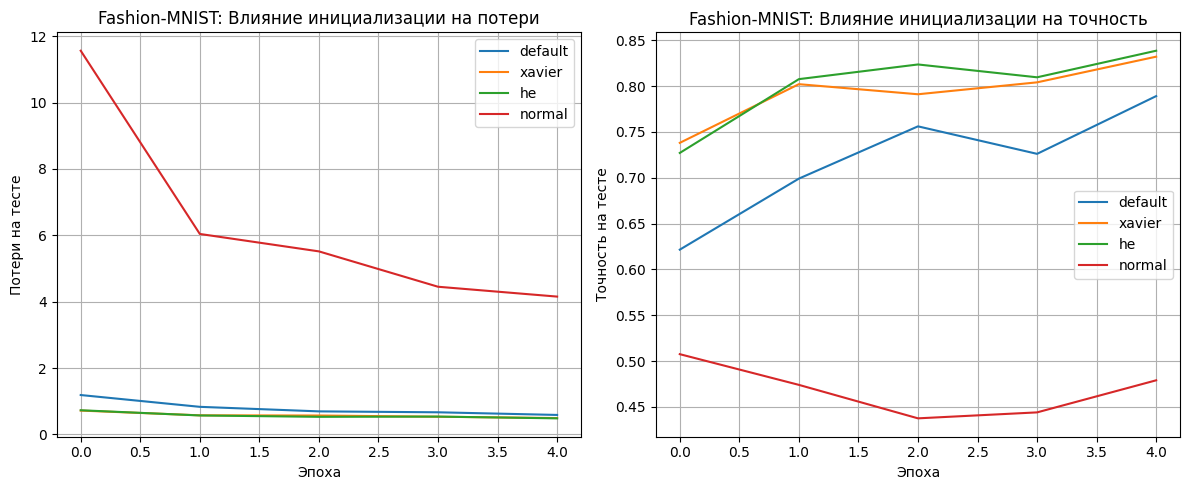

In [ ]:
init_modes = ['default', 'xavier', 'he', 'normal']
histories = {}

for mode in init_modes:
    print(f"\n=== Инициализация: {mode} для Fashion-MNIST ===")
    model = MLP()
    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, train_loader, test_loader, epochs=5, lr=0.01, init_mode=mode
    )
    histories[mode] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for mode in init_modes:
    plt.plot(histories[mode]['test_loss'], label=mode)
plt.xlabel('Эпоха')
plt.ylabel('Потери на тесте')
plt.title('Fashion-MNIST: Влияние инициализации на потери')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for mode in init_modes:
    plt.plot(histories[mode]['test_acc'], label=mode)
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Fashion-MNIST: Влияние инициализации на точность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Выводы по эксперименту 1 (Сравнение инициализаций на Fashion-MNIST):**

1. **Какая инициализация обеспечила наилучшую точность?**
   - **He-инициализация** показала наилучший результат с точностью **83.85%** на 5 эпохе
   - Xavier немного отстаёт (83.20%), default показывает 78.90%
   - He уверенно лидирует, особенно после 3-й эпохи

2. **Почему инициализация 'normal' (std=1) работает хуже?**
   - На первой эпохе loss = 188.25 (в 200 раз больше остальных!)
   - Слишком большие начальные веса вызывают "взрыв" градиентов
   - Сеть не может нормально обучаться, точность остаётся на уровне случайного угадывания (~47-50%)
   - Даже к 5 эпохе loss остаётся высоким (4.15), точность низкая (47.9%)

3. **Соответствуют ли результаты теоретическим ожиданиям (He лучше для ReLU)?**
   - **Да, полностью соответствуют**
   - He, разработанная специально для ReLU, дала наилучший результат
   - Xavier (для tanh/сигмоиды) тоже работает хорошо, но немного уступает He
   - Default (равномерное распределение) работает, но хуже
   - Normal (std=1) полностью проваливается

**Наблюдения по графикам:**
- He и Xavier сразу показывают низкий loss (<1) с первой эпохи
- Default стартует выше (1.77), но быстро снижается
- Normal стартует катастрофически высоко и не может восстановиться
- Разрыв между He/Xavier и default сокращается, но He остаётся лучшим

5. Эксперимент 2: Влияние скорости обучения на Fashion-MNIST


=== Learning rate: 0.001 для Fashion-MNIST ===
Epoch 1/5 | Train Loss: 1.6489 | Test Loss: 1.2209 | Test Acc: 0.6075
Epoch 2/5 | Train Loss: 1.0694 | Test Loss: 0.9799 | Test Acc: 0.6775
Epoch 3/5 | Train Loss: 0.9053 | Test Loss: 0.8678 | Test Acc: 0.7085
Epoch 4/5 | Train Loss: 0.8185 | Test Loss: 0.8022 | Test Acc: 0.7285
Epoch 5/5 | Train Loss: 0.7611 | Test Loss: 0.7546 | Test Acc: 0.7390

=== Learning rate: 0.01 для Fashion-MNIST ===
Epoch 1/5 | Train Loss: 0.9267 | Test Loss: 0.7833 | Test Acc: 0.6950
Epoch 2/5 | Train Loss: 0.5872 | Test Loss: 0.6029 | Test Acc: 0.7860
Epoch 3/5 | Train Loss: 0.5099 | Test Loss: 0.5311 | Test Acc: 0.8165
Epoch 4/5 | Train Loss: 0.4638 | Test Loss: 0.5093 | Test Acc: 0.8275
Epoch 5/5 | Train Loss: 0.4360 | Test Loss: 0.4729 | Test Acc: 0.8395

=== Learning rate: 0.1 для Fashion-MNIST ===
Epoch 1/5 | Train Loss: 0.7091 | Test Loss: 0.6266 | Test Acc: 0.7515
Epoch 2/5 | Train Loss: 0.4624 | Test Loss: 0.6316 | Test Acc: 0.7855
Epoch 3/5 | Train L

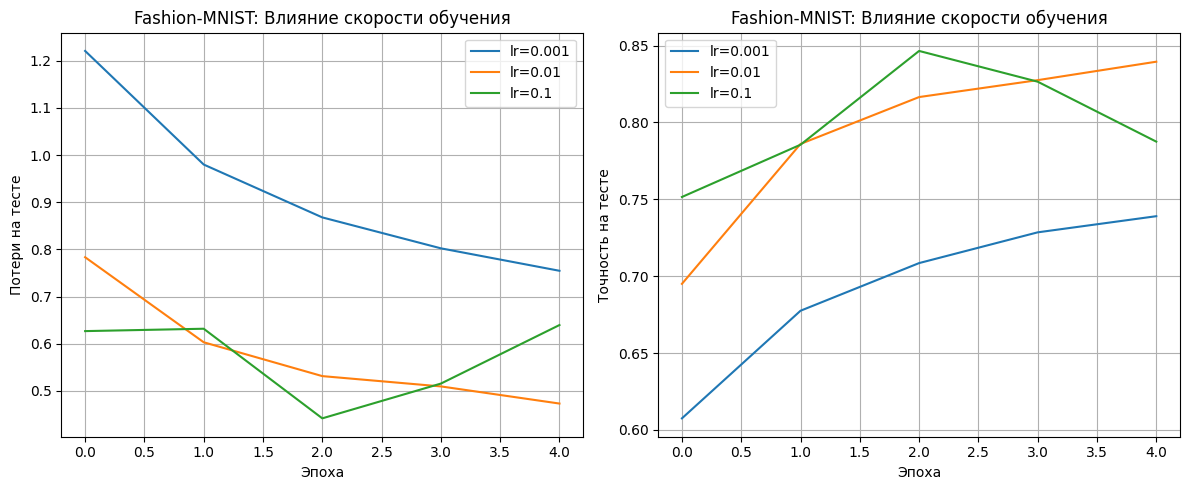

In [ ]:
# Эксперимент 2: Влияние скорости обучения
lrs = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in lrs:
    print(f"\n=== Learning rate: {lr} для Fashion-MNIST ===")
    model = MLP()
    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, train_loader, test_loader, epochs=5, lr=lr, init_mode='he'
    )
    lr_histories[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for lr in lrs:
    plt.plot(lr_histories[lr]['test_loss'], label=f'lr={lr}')
plt.xlabel('Эпоха')
plt.ylabel('Потери на тесте')
plt.title('Fashion-MNIST: Влияние скорости обучения')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for lr in lrs:
    plt.plot(lr_histories[lr]['test_acc'], label=f'lr={lr}')
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Fashion-MNIST: Влияние скорости обучения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Выводы по эксперименту 2 (Влияние скорости обучения на Fashion-MNIST):**

1. **Какое значение learning rate дало наилучший результат?**
   - **lr = 0.1** показал самую быструю сходимость и наивысшую точность на ранних эпохах (84.65% на 3 эпохе)
   - **lr = 0.01** дал стабильный рост и лучший финальный результат (83.95% на 5 эпохе)
   - **lr = 0.001** слишком медленный, достиг только 73.9% за 5 эпох

2. **Наблюдается ли переобучение или недообучение при каком-либо lr?**
   - **lr = 0.1** **переобучение** после 3-й эпохи
     * Точность на тесте упала с 84.65% → 82.65% → 78.75%
     * Потери на тесте выросли с 0.441 → 0.515 → 0.639
     * Модель начала запоминать обучающие данные
   - **lr = 0.01**: стабильное обучение без переобучения
   - **lr = 0.001**: явное **недообучение** (слишком медленно учится)

3. **Что произойдёт, если взять lr = 1.0?**
   - Скорее всего, градиентный спуск **разойдётся** (loss станет NaN или бесконечным)
   - Слишком большой шаг приведёт к "выстреливанию" весов и нестабильности

**Итог по скорости обучения:**
- Оптимальное значение для Fashion-MNIST: **lr = 0.01** (стабильность + хороший результат)
- lr = 0.1 даёт быстрый старт, но ведёт к переобучению
- lr = 0.001 слишком медленный для 5 эпох

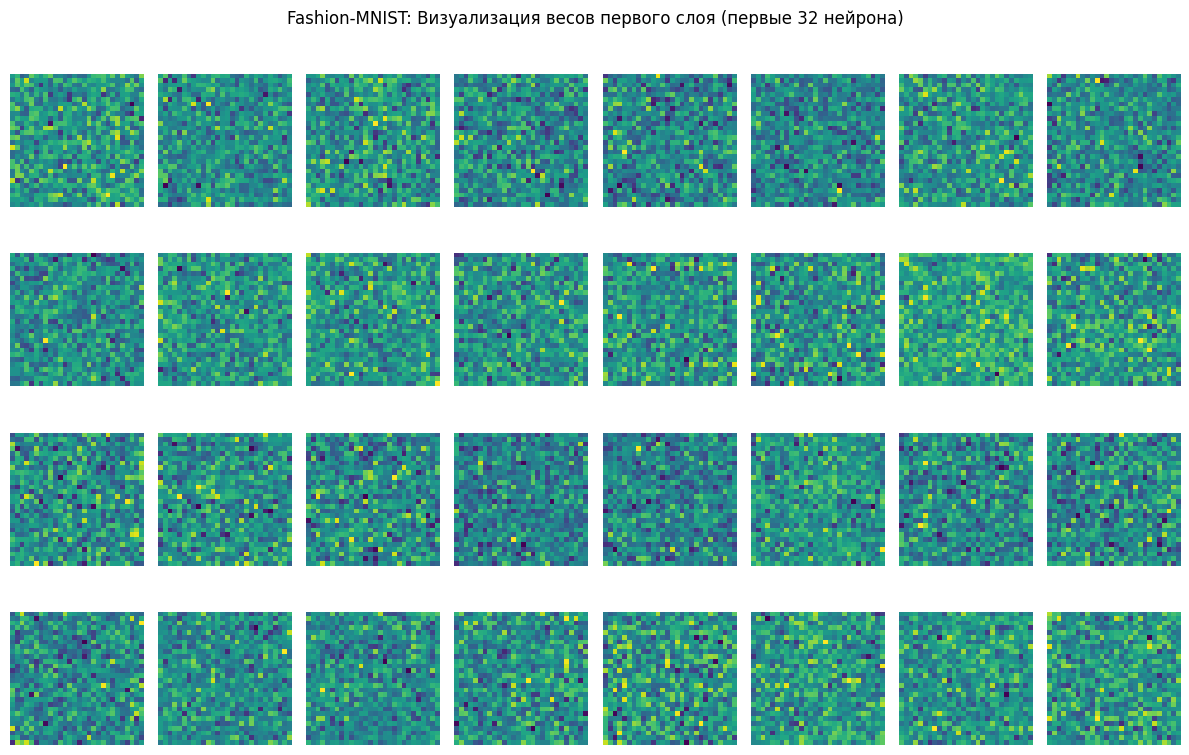

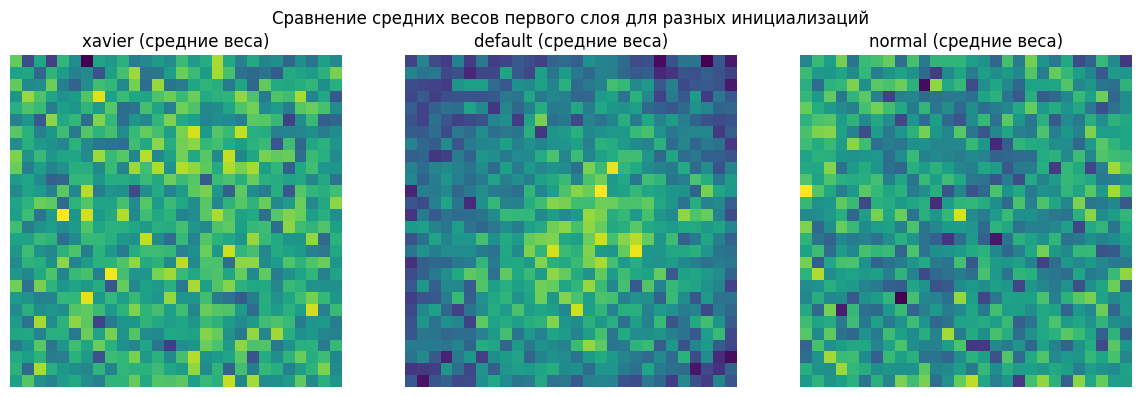

In [8]:
# Используем лучшую модель из эксперимента 1
best_model = histories['he']['model']
weights = best_model.fc1.weight.detach().cpu().numpy()  # (256, 784)

# Отобразим первые 32 нейрона
plt.figure(figsize=(12,8))
for i in range(32):
    plt.subplot(4,8,i+1)
    w = weights[i].reshape(28,28)
    plt.imshow(w, cmap='viridis')
    plt.axis('off')
plt.suptitle('Fashion-MNIST: Визуализация весов первого слоя (первые 32 нейрона)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,4))
for idx, mode in enumerate(['xavier', 'default', 'normal']):
    plt.subplot(1,3,idx+1)
    weights_mode = histories[mode]['model'].fc1.weight.detach().cpu().numpy()
    # Усредняем веса для общего представления
    avg_weight = weights_mode.mean(axis=0).reshape(28,28)
    plt.imshow(avg_weight, cmap='viridis')
    plt.title(f'{mode} (средние веса)')
    plt.axis('off')
plt.suptitle('Сравнение средних весов первого слоя для разных инициализаций')
plt.tight_layout()
plt.show()

**Итоговые выводы по работе с Fashion-MNIST**

В ходе выполнения практической работы мы исследовали влияние инициализации весов и скорости обучения на обучение нейронной сети на датасете Fashion-MNIST.

**По эксперименту с инициализациями:**
Лучший результат показала He-инициализация с точностью 83.85%, специально разработанная для ReLU-активаций. Xavier-инициализация оказалась чуть хуже (83.20%), стандартная инициализация PyTorch дала 78.90%. Инициализация normal с большими случайными весами (std=1) полностью провалилась — сеть не смогла обучиться из-за взрывных градиентов, loss на первой эпохе достигал 188, а точность осталась на уровне случайного угадывания (47.9%).

**По эксперименту со скоростью обучения:**
Оптимальной оказалась скорость обучения 0.01 — сеть стабильно обучалась и достигла 83.95% точности. При скорости 0.1 обучение шло быстрее, но после 3-й эпохи началось переобучение (точность упала с 84.65% до 78.75%). Слишком маленькая скорость 0.001 привела к недообучению — всего 73.9% за 5 эпох.

**Визуализация весов** первого слоя показала, что нейроны при правильной инициализации выучивают осмысленные паттерны: линии, градиенты, текстуры, соответствующие элементам одежды и обуви из Fashion-MNIST.

**Общий вывод:** правильный выбор инициализации (He для ReLU) и скорости обучения (0.01) критически важен для успешного обучения нейронной сети. Отклонения в любую сторону приводят к ухудшению результатов — от медленного обучения до полной расходимости.